In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error
import struct
import zipfile

def load_idx(f):
    magic = struct.unpack(">I", f.read(4))[0]

    if magic == 2051:
        num, rows, cols = struct.unpack(">III", f.read(12))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(num, rows, cols)

    elif magic == 2049:
        num = struct.unpack(">I", f.read(4))[0]
        return np.frombuffer(f.read(), dtype=np.uint8)

def load_mnist_zip(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        X_train = load_idx(z.open("archive/train-images.idx3-ubyte"))
        y_train = load_idx(z.open("archive/train-labels.idx1-ubyte"))
        X_test  = load_idx(z.open("archive/t10k-images.idx3-ubyte"))
        y_test  = load_idx(z.open("archive/t10k-labels.idx1-ubyte"))
    return (X_train, y_train), (X_test, y_test)

(X_train, y_train), (X_test, y_test) = load_mnist_zip("archive.zip")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Training shape: {X_train_flat.shape}")
print(f"Test shape: {X_test_flat.shape}")

Training shape: (60000, 784)
Test shape: (10000, 784)


In [3]:
X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    X_train_flat, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print(f"Train: {X_train_sub.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test_final.shape}")

Train: (36000, 784)
Validation: (12000, 784)
Test: (12000, 784)


In [4]:
df_train = pd.DataFrame(X_train_scaled[:1000, :10])
print("Descriptive Statistics (first 10 features):")
print(df_train.describe())

baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_rf.fit(X_train_scaled, y_train_sub)

y_val_pred = baseline_rf.predict(X_val_scaled)
print(f"Baseline Random Forest Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")

baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(X_train_scaled, y_train_sub)
y_val_pred_lr = baseline_lr.predict(X_val_scaled)
print(f"Baseline Logistic Regression Accuracy: {accuracy_score(y_val, y_val_pred_lr):.4f}")

Descriptive Statistics (first 10 features):
            0       1       2       3       4       5       6       7       8  \
count  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0   
mean      0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
std       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
min       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
25%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
50%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
75%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
max       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

            9  
count  1000.0  
mean      0.0  
std       0.0  
min       0.0  
25%       0.0  
50%       0.0  
75%       0.0  
max       0.0  
Baseline Random Forest Accuracy: 0.9652
Baseline Logistic Regression Accuracy: 0.9

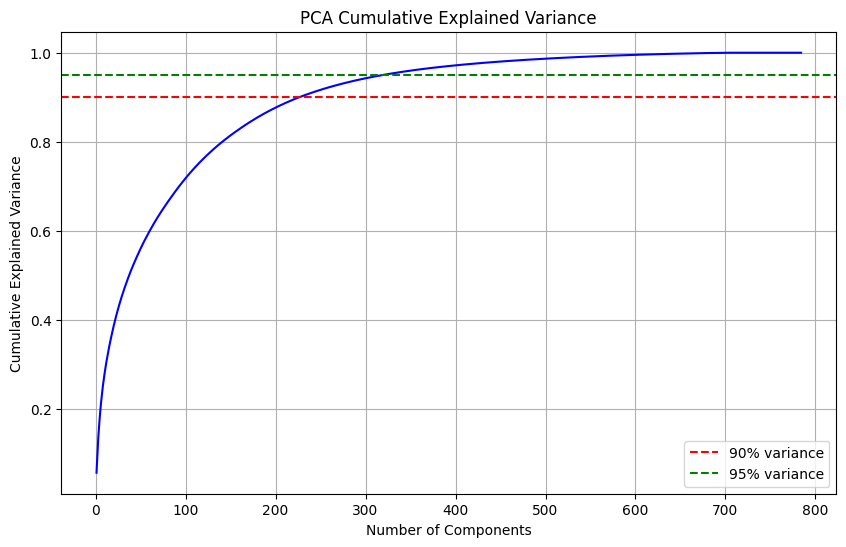

Components needed for 90% variance: 227
Components needed for 95% variance: 320
PCA with 2 components: Explained variance = 0.0983
PCA with 10 components: Explained variance = 0.2802
PCA with 50 components: Explained variance = 0.5603
PCA with 227 components: Explained variance = 0.9006
PCA with 320 components: Explained variance = 0.9503


In [5]:
pca = PCA(random_state=42)

pca.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")

component_values = [2, 10, 50, n_components_90, n_components_95]

pca_models = {}
X_train_pca = {}
X_val_pca = {}

for n in component_values:
    pca = PCA(n_components=n, random_state=42)
    X_train_pca[n] = pca.fit_transform(X_train_scaled)
    X_val_pca[n] = pca.transform(X_val_scaled)
    pca_models[n] = pca
    print(f"PCA with {n} components: Explained variance = {pca.explained_variance_ratio_.sum():.4f}")

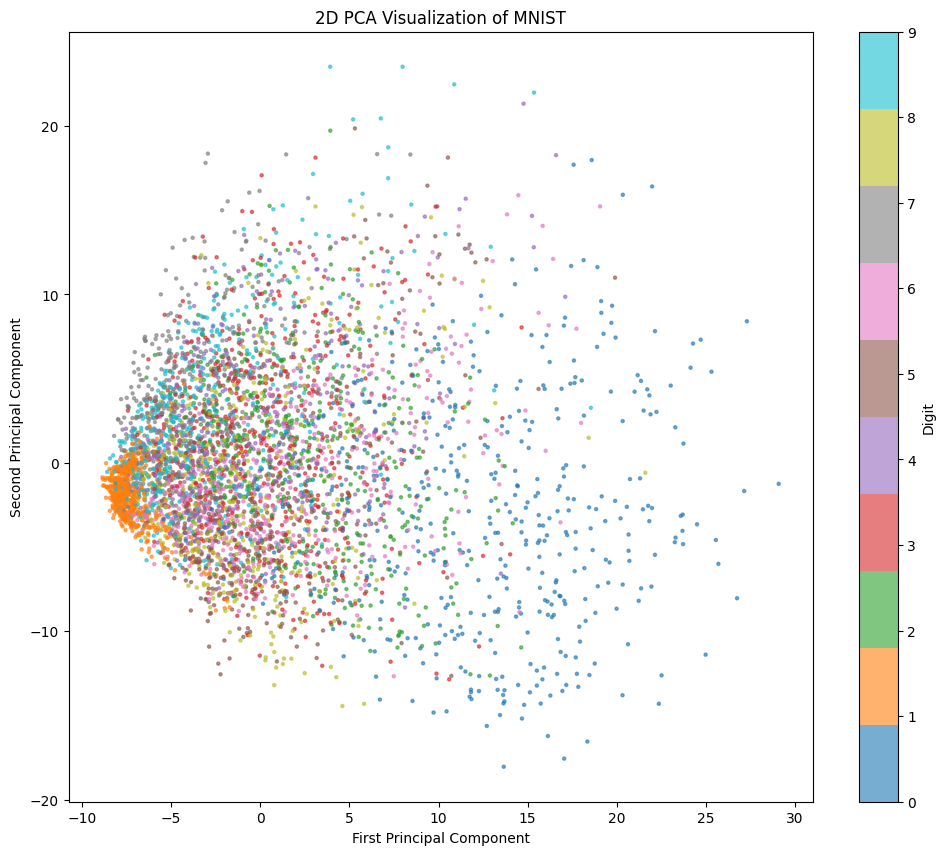

In [6]:
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled[:5000])
y_train_subset = y_train_sub[:5000]

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], 
                       c=y_train_subset, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, label='Digit')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D PCA Visualization of MNIST')
plt.show()

Reconstruction error for 2 components: 1.503060
Reconstruction error for 10 components: 1.339599
Reconstruction error for 50 components: 1.097358
Reconstruction error for 227 components: 0.371449
Reconstruction error for 320 components: 0.141493


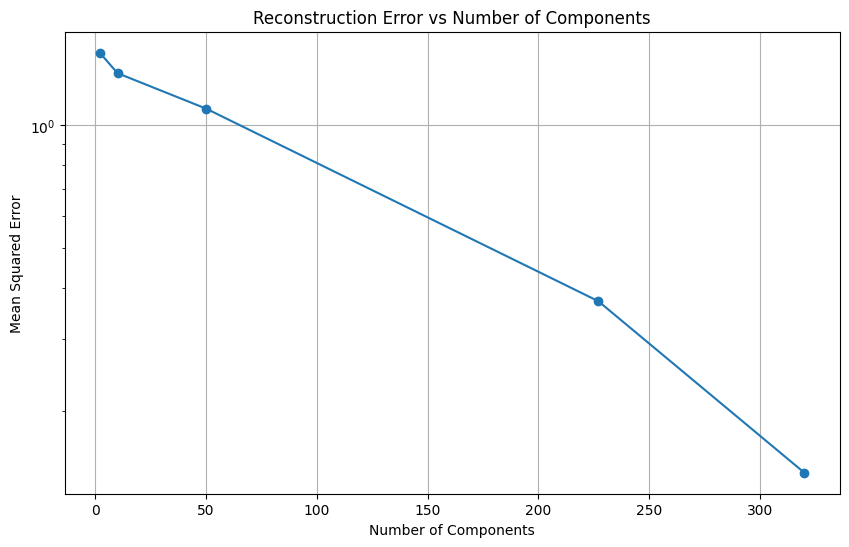

In [7]:
reconstruction_errors = {}

for n in component_values:

    X_reconstructed = pca_models[n].inverse_transform(X_val_pca[n])

    mse = mean_squared_error(X_val_scaled, X_reconstructed)
    reconstruction_errors[n] = mse
    print(f"Reconstruction error for {n} components: {mse:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(list(reconstruction_errors.keys()), list(reconstruction_errors.values()), 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Mean Squared Error')
plt.title('Reconstruction Error vs Number of Components')
plt.yscale('log')
plt.grid(True)
plt.show()

In [8]:
pca_results = {}

for n in component_values:

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_pca[n], y_train_sub)
    y_pred = rf.predict(X_val_pca[n])
    acc = accuracy_score(y_val, y_pred)
    pca_results[n] = {'RF_accuracy': acc}

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_pca[n], y_train_sub)
    y_pred_lr = lr.predict(X_val_pca[n])
    pca_results[n]['LR_accuracy'] = accuracy_score(y_val, y_pred_lr)
    
    print(f"Components={n}: RF Acc={acc:.4f}, LR Acc={pca_results[n]['LR_accuracy']:.4f}")

pca_df = pd.DataFrame(pca_results).T
print("\nPCA Results Summary:")
print(pca_df)

Components=2: RF Acc=0.3220, LR Acc=0.3350
Components=10: RF Acc=0.8957, LR Acc=0.7948
Components=50: RF Acc=0.9398, LR Acc=0.8998
Components=227: RF Acc=0.9327, LR Acc=0.9189
Components=320: RF Acc=0.9258, LR Acc=0.9173

PCA Results Summary:
     RF_accuracy  LR_accuracy
2       0.322000     0.335000
10      0.895667     0.794833
50      0.939833     0.899833
227     0.932667     0.918917
320     0.925833     0.917250


LDA transformed shape: (36000, 9)


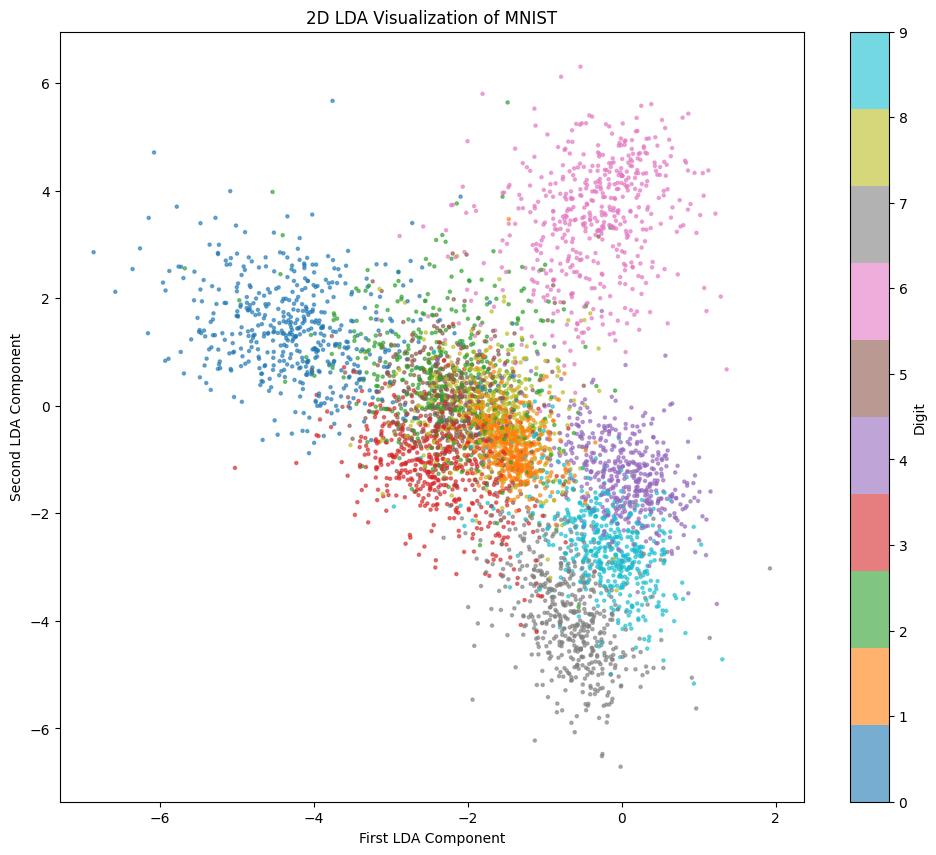

In [9]:
lda = LDA(n_components=9)
X_train_lda = lda.fit_transform(X_train_scaled, y_train_sub)
X_val_lda = lda.transform(X_val_scaled)

print(f"LDA transformed shape: {X_train_lda.shape}")

lda_2d = LDA(n_components=2)
X_train_lda_2d = lda_2d.fit_transform(X_train_scaled[:5000], y_train_sub[:5000])

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_train_lda_2d[:, 0], X_train_lda_2d[:, 1], 
                       c=y_train_sub[:5000], cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, label='Digit')
plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('2D LDA Visualization of MNIST')
plt.show()

In [10]:
lda_components = [2, 5, 9]
lda_results = {}

for n in lda_components:
    lda_model = LDA(n_components=n)
    X_train_lda_n = lda_model.fit_transform(X_train_scaled, y_train_sub)
    X_val_lda_n = lda_model.transform(X_val_scaled)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_lda_n, y_train_sub)
    acc_rf = accuracy_score(y_val, rf.predict(X_val_lda_n))

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_lda_n, y_train_sub)
    acc_lr = accuracy_score(y_val, lr.predict(X_val_lda_n))
    
    lda_results[n] = {'RF_accuracy': acc_rf, 'LR_accuracy': acc_lr}
    print(f"LDA components={n}: RF Acc={acc_rf:.4f}, LR Acc={acc_lr:.4f}")

best_pca_n = max(pca_results.keys(), key=lambda x: pca_results[x]['RF_accuracy'])
print(f"\nBest PCA ({best_pca_n} components) RF Accuracy: {pca_results[best_pca_n]['RF_accuracy']:.4f}")
print(f"Best LDA (9 components) RF Accuracy: {lda_results[9]['RF_accuracy']:.4f}")

LDA components=2: RF Acc=0.5317, LR Acc=0.5616
LDA components=5: RF Acc=0.8378, LR Acc=0.8198
LDA components=9: RF Acc=0.9046, LR Acc=0.8772

Best PCA (50 components) RF Accuracy: 0.9398
Best LDA (9 components) RF Accuracy: 0.9046


In [11]:
X_centered = X_train_scaled - np.mean(X_train_scaled, axis=0)

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"S shape: {S.shape}")
print(f"Vt shape: {Vt.shape}")

pca_check = PCA()
pca_check.fit(X_train_scaled)

print("First 5 PCA components (first 10 features):")
print(pca_check.components_[:5, :10])
print("\nFirst 5 SVD right singular vectors (first 10 features):")
print(Vt[:5, :10])

np.allclose(np.abs(pca_check.components_[:5, :10]), np.abs(Vt[:5, :10]))

U shape: (36000, 784)
S shape: (784,)
Vt shape: (784, 784)
First 5 PCA components (first 10 features):
[[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]]

First 5 SVD right singular vectors (first 10 features):
[[ 3.79012091e-19  1.11022302e-16  2.22044605e-16 -5.55111512e-17
   0.00000000e+00  0.00000000e+00  8.67361738e-19  0.00000000e+00
   1.08420217e-19  0.00000000e+00]
 [ 1.96346579e-21  1.12757026e-17 -3.05745013e-17 -5.20417043e-18
  -3.29597460e-17 -2.77555756e-17  6.24500451e-17 -5.20417043e-17
  -5.55111512e-17 -5.55111512e-17]
 [-1.49665561e-19 -2.77555756e-17 -5.55111512e-17 -1.94289029e-16
   3.33066907e-16 -1.11022302e-16  5.55111512e-17  2.77555756e-17
   0.00000000e+00  3.46944695e-18]
 [ 1.43506230e-19  8.32667268e-17  3.81639165e-17 -5.55111512e-17
   2.77555756e-17 -6.93889390e-17  8.32667268e-17 -5.5511

True

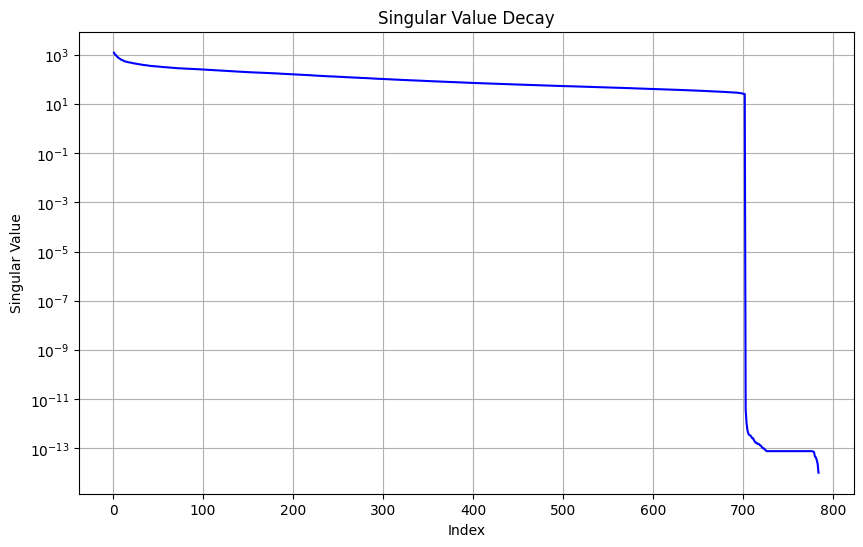

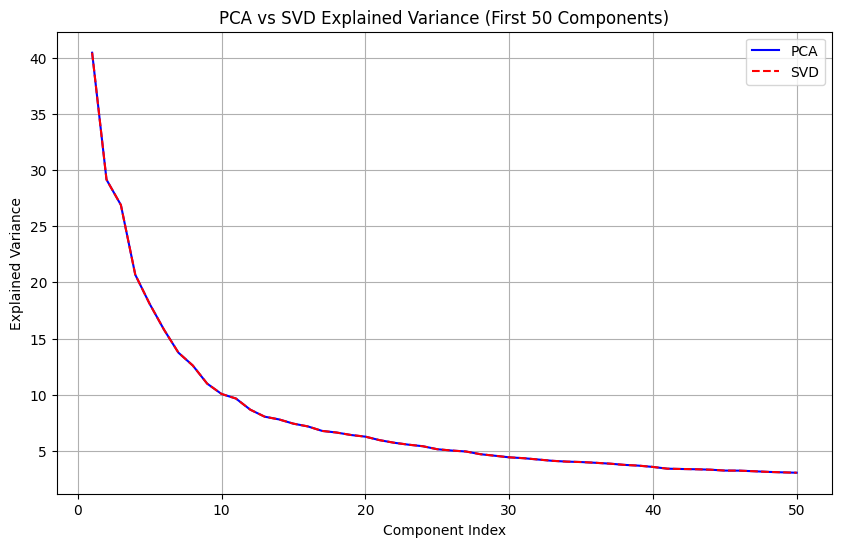

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(S) + 1), S, 'b-')
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.title('Singular Value Decay')
plt.yscale('log')
plt.grid(True)
plt.show()

explained_variance_pca = pca_check.explained_variance_
explained_variance_svd = S**2 / (X_centered.shape[0] - 1)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 51), explained_variance_pca[:50], 'b-', label='PCA')
plt.plot(range(1, 51), explained_variance_svd[:50], 'r--', label='SVD')
plt.xlabel('Component Index')
plt.ylabel('Explained Variance')
plt.title('PCA vs SVD Explained Variance (First 50 Components)')
plt.legend()
plt.grid(True)
plt.show()

SVD reconstruction error for k=2: 0.814311
SVD reconstruction error for k=10: 0.649991
SVD reconstruction error for k=50: 0.397043
SVD reconstruction error for k=100: 0.254376
SVD reconstruction error for k=200: 0.111315


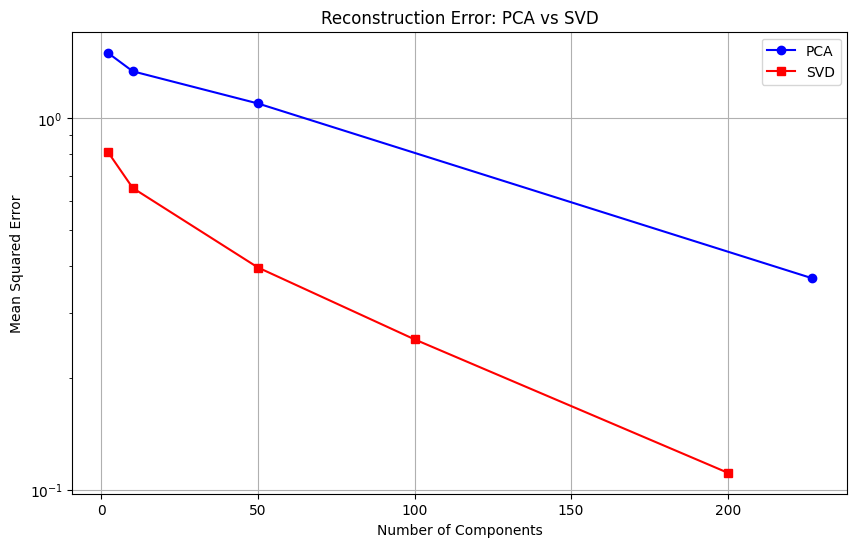

In [13]:
svd_reconstruction_errors = {}

for k in [2, 10, 50, 100, 200]:

    X_reconstructed_svd = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

    mse = mean_squared_error(X_centered, X_reconstructed_svd)
    svd_reconstruction_errors[k] = mse
    print(f"SVD reconstruction error for k={k}: {mse:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(list(pca_models.keys())[:4], [reconstruction_errors[n] for n in list(pca_models.keys())[:4]], 
         'bo-', label='PCA')
plt.plot(list(svd_reconstruction_errors.keys()), list(svd_reconstruction_errors.values()), 
         'rs-', label='SVD')
plt.xlabel('Number of Components')
plt.ylabel('Mean Squared Error')
plt.title('Reconstruction Error: PCA vs SVD')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score

pca_cv_scores = {}
component_range = [10, 50, 100, 200, 300]

for n in component_range:
    pca_cv = PCA(n_components=n, random_state=42)
    X_pca_cv = pca_cv.fit_transform(X_train_scaled)
    
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_pca_cv, y_train_sub, cv=5, scoring='accuracy')
    pca_cv_scores[n] = scores.mean()
    print(f"PCA components={n}: CV Accuracy={scores.mean():.4f} (+/- {scores.std():.4f})")

best_pca_cv = max(pca_cv_scores, key=pca_cv_scores.get)
print(f"\nBest PCA components from CV: {best_pca_cv}")

PCA components=10: CV Accuracy=0.8943 (+/- 0.0038)
PCA components=50: CV Accuracy=0.9364 (+/- 0.0008)
PCA components=100: CV Accuracy=0.9349 (+/- 0.0029)
PCA components=200: CV Accuracy=0.9277 (+/- 0.0025)
PCA components=300: CV Accuracy=0.9216 (+/- 0.0023)

Best PCA components from CV: 50


In [15]:
pca_final = PCA(n_components=best_pca_cv, random_state=42)
X_train_pca_final = pca_final.fit_transform(X_train_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

lda_final = LDA(n_components=9)
X_train_lda_final = lda_final.fit_transform(X_train_scaled, y_train_sub)
X_test_lda_final = lda_final.transform(X_test_scaled)

final_results = {}

for name, X_tr, X_te in [('Raw', X_train_scaled, X_test_scaled),
                          ('PCA', X_train_pca_final, X_test_pca_final),
                          ('LDA', X_train_lda_final, X_test_lda_final)]:

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_train_sub)
    y_pred = rf.predict(X_te)
    
    final_results[name] = {
        'RF_Accuracy': accuracy_score(y_test_final, y_pred),
        'RF_CM': confusion_matrix(y_test_final, y_pred)
    }

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr, y_train_sub)
    y_pred_lr = lr.predict(X_te)
    final_results[name]['LR_Accuracy'] = accuracy_score(y_test_final, y_pred_lr)

results_df = pd.DataFrame({
    name: {'RF Accuracy': res['RF_Accuracy'], 'LR Accuracy': res['LR_Accuracy']}
    for name, res in final_results.items()
}).T
print("\nFinal Test Results:")
print(results_df)


Final Test Results:
     RF Accuracy  LR Accuracy
Raw     0.963583     0.906333
PCA     0.943167     0.904000
LDA     0.904250     0.880500


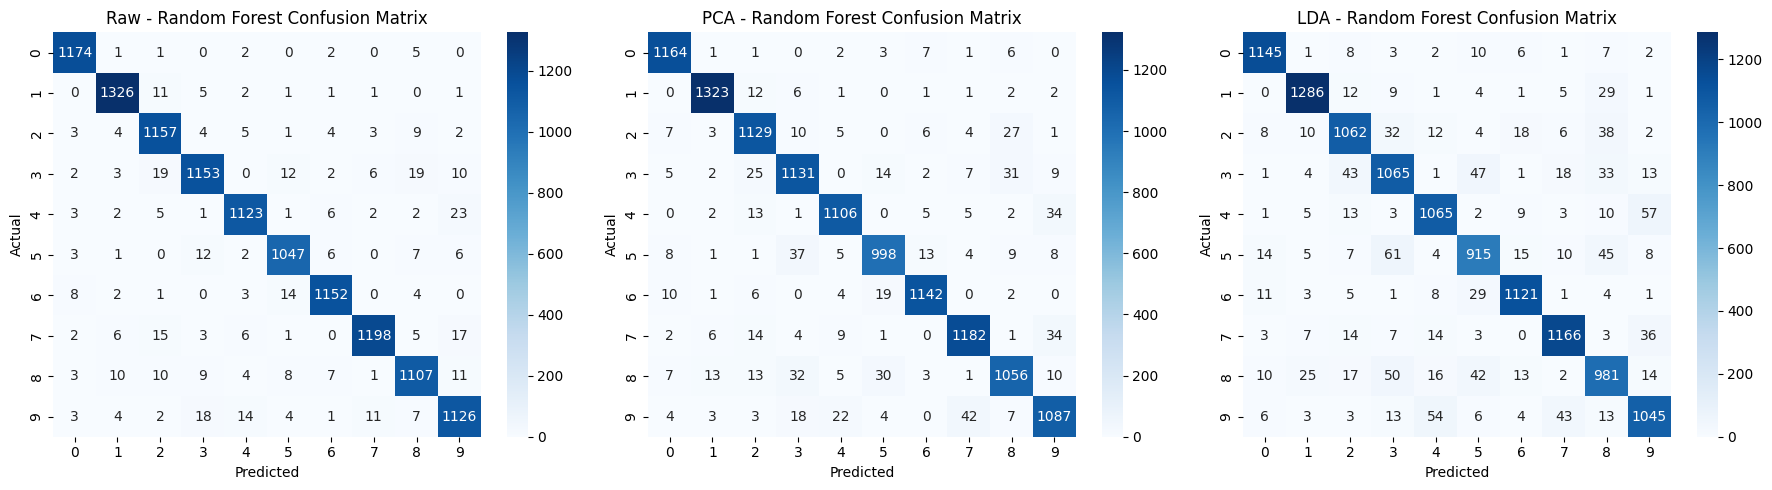

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(final_results.items()):
    sns.heatmap(res['RF_CM'], annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} - Random Forest Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [17]:
summary = pd.DataFrame({
    'Method': ['Raw', 'PCA', 'LDA'],
    'Best RF Accuracy': [final_results['Raw']['RF_Accuracy'], 
                         final_results['PCA']['RF_Accuracy'],
                         final_results['LDA']['RF_Accuracy']],
    'Best LR Accuracy': [final_results['Raw']['LR_Accuracy'],
                         final_results['PCA']['LR_Accuracy'],
                         final_results['LDA']['LR_Accuracy']],
    'Dimensionality': [784, best_pca_cv, 9]
})

print(summary.to_string(index=False))

Method  Best RF Accuracy  Best LR Accuracy  Dimensionality
   Raw          0.963583          0.906333             784
   PCA          0.943167          0.904000              50
   LDA          0.904250          0.880500               9
